Hermann Hesse - Steppenwolf: 75864 слов
Franz Kafka - Metamorphosis: 22377 слов
Fyodor Dostoevsky - Notes from the Underground: 44733 слов
Hermann Hesse - Siddhartha: 39799 слов
Franz Kafka - The Trial: 84327 слов
Fyodor Dostoevsky - Crime and Punishment: 209022 слов
Friedrich Nietzsche - Thus Spake Zarathustra: 113582 слов

Частота на 1000 слов:
theme                death  freedom  anxiety  absurd  solitude
author                                                        
Franz Kafka           0.12     0.57     0.38    0.04      0.23
Friedrich Nietzsche   1.70     0.76     0.34    0.05      0.86
Fyodor Dostoevsky     0.86     0.35     0.96    0.46      0.47
Hermann Hesse         1.64     0.25     0.77    0.10      0.82


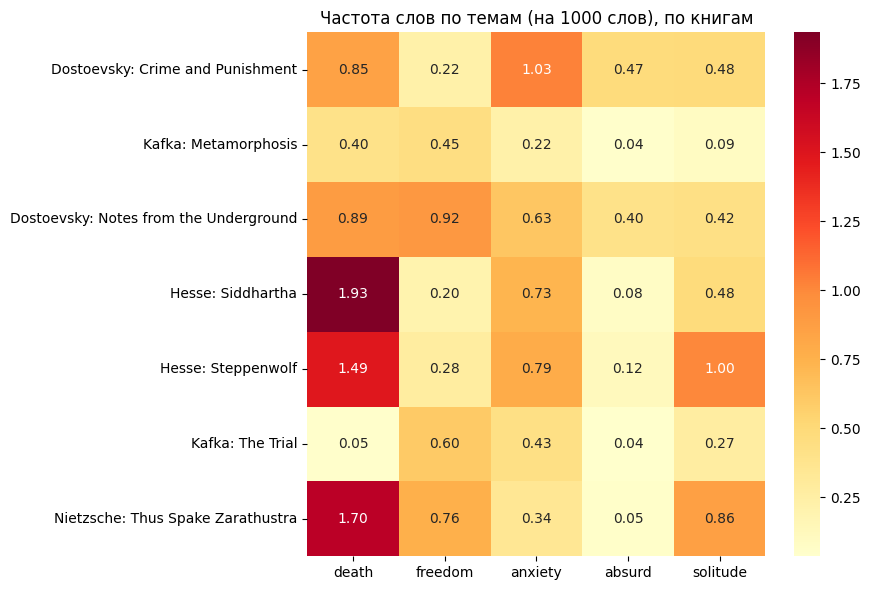

In [10]:
import random
import requests, re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BOOKS = [
    ("Hermann Hesse", "Steppenwolf", 75756),
    ("Franz Kafka", "Metamorphosis", 5200),
    ("Fyodor Dostoevsky", "Notes from the Underground", 600),
    ("Hermann Hesse", "Siddhartha", 2500),
    ("Franz Kafka", "The Trial", 7849),
    ("Fyodor Dostoevsky", "Crime and Punishment", 2554),
    ("Friedrich Nietzsche", "Thus Spake Zarathustra", 1998),
]

THEMES = {
    "death":    ["death", "die", "died", "dying", "dead", "grave", "corpse"],
    "freedom":  ["free", "freedom", "liberty", "choice", "choose"],
    "anxiety":  ["anxiety", "dread", "fear", "terror", "afraid", "anguish"],
    "absurd":   ["absurd", "meaningless", "senseless", "nonsense", "futile"],
    "solitude": ["alone", "lonely", "solitude", "isolation", "loneliness"],
}


def load_book(book_id):
    """Download a book from Project Gutenberg and return a list of lowercase words."""
    url = f"https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt"
    r = requests.get(url)
    r.raise_for_status()
    text = r.text
    start = re.search(r"\*\*\* ?START OF.*?\*\*\*", text)
    end = re.search(r"\*\*\* ?END OF.*?\*\*\*", text)
    if start and end:
        text = text[start.end():end.start()]
    return re.findall(r"[a-z']+", text.lower())


corpus = {}
rows = []

for author, title, book_id in BOOKS:
    try:
        words = load_book(book_id)
    except Exception as e:
        print(f"Could not download {title} ({book_id}): {e}")
        continue
    corpus[title] = words
    print(f"{author} - {title}: {len(words)} words")
    for theme, keys in THEMES.items():
        count = sum(words.count(k) for k in keys)
        rows.append({"author": author, "title": title, "theme": theme,
                     "count": count, "total_words": len(words)})

df = pd.DataFrame(rows)

by_author = df.groupby(["author", "theme"]).agg(
    count=("count", "sum"),
    total_words=("total_words", "sum")
).reset_index()
by_author["per_1000"] = by_author["count"] / by_author["total_words"] * 1000

table = by_author.pivot(index="author", columns="theme", values="per_1000")
table = table[list(THEMES.keys())]
print("\nFrequency per 1,000 words:")
print(table.round(2))

df["per_1000"] = df["count"] / df["total_words"] * 1000
per_book = df.pivot(index="title", columns="theme", values="per_1000")[list(THEMES.keys())]

labels = {t: f"{a.split()[-1]}: {t}" for a, t, _ in BOOKS}
per_book_plot = per_book.rename(index=labels)

plt.figure(figsize=(9, 6))
sns.heatmap(per_book_plot, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Theme word frequency per 1,000 words, by book")
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.savefig("heatmap_books.png", dpi=200)
plt.show()


def kwic(word, title, n=5, window=8, seed=1):
    """Print n random examples of a word together with the words around it."""
    words = corpus[title]
    idx = [i for i, w in enumerate(words) if w == word]
    random.seed(seed)
    for i in random.sample(idx, min(n, len(idx))):
        print("...", " ".join(words[max(0, i - window): i + window + 1]), "...")
    print()

In [16]:
df["per_1000"] = df["count"] / df["total_words"] * 1000
per_book = df.pivot(index="title", columns="theme", values="per_1000")[list(THEMES.keys())]
print(per_book.round(2))


theme                       death  freedom  anxiety  absurd  solitude
title                                                                
Crime and Punishment         0.85     0.22     1.03    0.47      0.48
Metamorphosis                0.40     0.45     0.22    0.04      0.09
Notes from the Underground   0.89     0.92     0.63    0.40      0.42
Siddhartha                   1.93     0.20     0.73    0.08      0.48
Steppenwolf                  1.49     0.28     0.79    0.12      1.00
The Trial                    0.05     0.60     0.43    0.04      0.27
Thus Spake Zarathustra       1.70     0.76     0.34    0.05      0.86
